## Kernel PCA : an attempt


This notebook, utilises the resources of Machine Learning Techniques course of IIT Madras. My aim is to see in code, the intricasies of kernelised PCA

In [1]:
# Imports 
import numpy as np 
import matplotlib.pyplot as plt 

In [2]:
X = np.array([[1, 1], [2, 4], [-1, 1], [-2, 4]]).T

In [3]:
print(X)

[[ 1  2 -1 -2]
 [ 1  4  1  4]]


Text(0.5, 1.0, 'The Dataset')

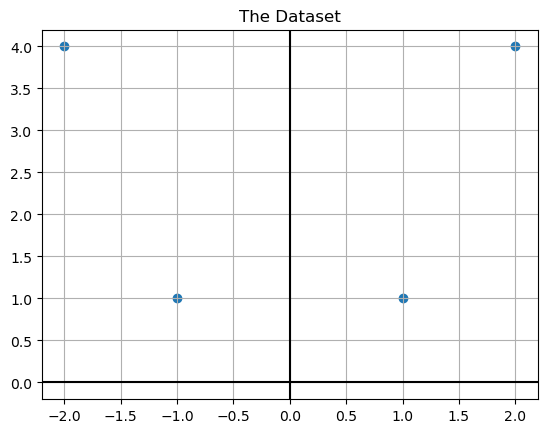

In [5]:
# Visualize the data set
plt.scatter(X[0, :], X[1, :])
plt.axhline(c="k")
plt.axvline(c="k")
plt.grid()
plt.title("The Dataset")

### 1. <u>Calculation of Kernel matrix </u>

$K_{ij} = k(x_{i}, x_{j})$

In [7]:
# we will write the polynomial kernel 

def pol_kernel(A, B, k): 
    # k is the order 
    return (A.T @ B + 1) ** k 

K_poly = pol_kernel(X, X, 2)
K_poly

array([[  9,  49,   1,   9],
       [ 49, 441,   9, 169],
       [  1,   9,   9,  49],
       [  9, 169,  49, 441]])

### 2. <u>Centering the Kernel : </u>
$K^{c} = K - IK - KI + IKI$
where $K^{c}$ is the centered kernel, and I belongs to the n cross n space , where all elements are 1/n

In [8]:
def center(K): 
    n = K.shape[0]
    I = np.ones((n , n)) * (1/n) # and array of all 1/n 's 
    return K - I@K - K@I + I@K@I 

Kc = center(K_poly)


In [9]:
Kc

array([[ 67., -43.,  59., -83.],
       [-43., 199., -83., -73.],
       [ 59., -83.,  67., -43.],
       [-83., -73., -43., 199.]])

### <u>3. Compute the eigenvectors $\beta_{1}, \beta_{2}, \beta_{3}, ... , \beta_{n}$ and eigenvalues $n\lambda_{1}, ... , n\lambda_{n}$  of  $K$<sup>C</sup></u>

In [19]:
lamda, beta = np.linalg.eigh(Kc)
lamda, beta = lamda[::-1][:-1], beta[:, ::-1][:, :-1]

In [20]:
lamda, beta

(array([277.9275172, 252.       ,   2.0724828]),
 array([[ 0.10365278, -0.5       , -0.69946844],
        [ 0.69946844,  0.5       ,  0.10365278],
        [-0.10365278, -0.5       ,  0.69946844],
        [-0.69946844,  0.5       , -0.10365278]]))

In [21]:
# computing the coefficients : alphas 

alp = beta / np.sqrt(lamda.reshape(1, -1)) # convert a column vector to a row vector 

In [22]:
alp

array([[ 0.00621749, -0.03149704, -0.48587288],
       [ 0.0419568 ,  0.03149704,  0.0720005 ],
       [-0.00621749, -0.03149704,  0.48587288],
       [-0.0419568 ,  0.03149704, -0.0720005 ]])

In [23]:
X_prime = Kc@alp
X_prime

array([[  1.72801191,  -7.93725393,  -1.00696319],
       [ 11.66094908,   7.93725393,   0.14921979],
       [ -1.72801191,  -7.93725393,   1.00696319],
       [-11.66094908,   7.93725393,  -0.14921979]])

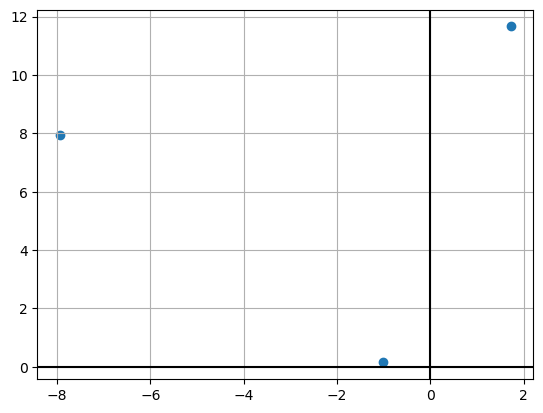

In [24]:
plt.scatter(X_prime[0, :], X_prime[1 , :])
plt.axhline(c = "k")
plt.axvline(c = "k")
plt.grid()